In [166]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
import optuna
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score
from sklearn.feature_selection import RFECV, mutual_info_classif


recall=  TP / (TP + FN)
precision = TP / (TP + FP)

In [298]:
with open('../../data/enhanced_trades_df_v2.pkl', 'rb') as f:
    trades = pickle.load(f)

In [299]:
# trades["random_feature"] = np.random.randn(len(trades))

In [300]:
trades

,Symbol,entry_date,entry_price,exit_date,exit_price,return,Close,stock_ret_1d,rsi,adx,...,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,result,Industry,hmm_cluster,Industry_woe,cluster_win_loss_ratio
2396,NMDC,2016-03-09,13.149165,2016-04-28,13.738341,4.480711,13.149165,-0.015344,75.574806,33.866604,...,0.000438,-0.943376,13.231202,1.863594,0.137517,1,Metals & Mining,0.0,0.171921,0.815166
1419,HINDALCO,2016-03-21,80.699150,2016-03-30,82.575851,2.325553,80.699150,0.009390,66.985118,30.847063,...,0.000358,-0.152065,33.855358,0.968967,0.063425,1,Metals & Mining,3.0,0.171921,0.512195
3240,TATASTEEL,2016-03-21,22.325666,2016-05-05,24.403414,9.306541,22.325666,0.004467,73.931740,30.156950,...,0.000155,-0.579234,35.126138,1.071643,0.016532,1,Metals & Mining,3.0,0.171921,0.512195
598,BHARTIARTL,2016-03-22,299.554504,2016-04-01,286.365204,-4.402972,299.554504,-0.007776,68.502922,30.521119,...,0.000175,0.457509,83.115273,1.333358,0.015242,0,Telecommunication,3.0,-0.170878,0.512195
2815,RELIANCE,2016-03-22,229.608643,2016-03-28,223.593719,-2.619641,229.608643,0.010171,67.560319,30.172319,...,0.000280,0.116702,80.890779,1.781608,0.113989,0,Oil Gas & Consumable Fuels,3.0,0.041870,0.512195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1692,INDIGO,2025-08-27,6050.000000,2025-08-28,5727.000000,-5.338843,6050.000000,0.000000,57.705115,30.314948,...,0.000106,3.992301,603.398978,0.451727,0.000000,0,Services,1.0,-0.240706,0.744048
3580,VMM,2025-08-27,153.139999,2025-09-02,146.330002,-4.446910,153.139999,0.000000,68.060884,31.580026,...,0.000392,1.153450,218.252956,2.544196,0.000000,0,Consumer Services,1.0,0.189966,0.744048
3360,TITAN,2025-08-29,3628.800049,2025-09-15,3534.100098,-2.609677,3628.800049,-0.002447,64.093506,31.060234,...,0.000062,-0.379968,97.851273,1.078735,0.072640,0,Consumer Durables,1.0,0.183092,0.744048
2209,MFSL,2025-08-29,1602.199951,2025-09-04,1566.000000,-2.259390,1602.199951,-0.004041,53.859737,30.395963,...,0.000116,-0.450856,49.298656,0.452576,-0.124731,0,Financial Services,1.0,-0.029508,0.744048


In [301]:
trades["result"] = np.where(trades["return"] > 0, 1, 0)

In [302]:
print(trades["result"].value_counts())

result
0    2166
1    1503
Name: count, dtype: int64


In [303]:
trades.columns

Index(['Symbol', 'entry_date', 'entry_price', 'exit_date', 'exit_price',
       'return', 'Close', 'stock_ret_1d', 'rsi', 'adx', 'Index_Close',
       'index_ret_1d', 'index_ret_5d', 'index_ret_20d', 'index_vol',
       'index_vol_5d', 'index_vol_20d', 'plus_di', 'minus_di', 'rsi_5_chg',
       'adx_5_chg', 'roc_5', 'atr_5_chg', 'vol_chg_5d', 'volatility_5d',
       '5_days_high', 'rsi_10_chg', 'adx_10_chg', 'roc_10', 'atr_10_chg',
       'vol_chg_10d', 'volatility_10d', '10_days_high', 'rsi_20_chg',
       'adx_20_chg', 'roc_20', 'atr_20_chg', 'vol_chg_20d', 'volatility_20d',
       '20_days_high', 'beta', 'corr', 'stock_vol', 'excess_vol',
       'volatility_of_volatility', 'dsv', 'vol_z', 'vol_vol_ratio', 'obv_z',
       'vwap_dev', 'result', 'Industry', 'hmm_cluster', 'Industry_woe',
       'cluster_win_loss_ratio'],
      dtype='object')

In [304]:
to_drop = ["Symbol", "entry_price", "exit_date","exit_price","Close","return" ,"Industry", "Index_Close", 'entry_date', '10_days_high', '20_days_high', '5_days_high','index_vol','stock_vol']

In [305]:
df= trades.drop(columns=to_drop)

In [306]:
df

,stock_ret_1d,rsi,adx,index_ret_1d,index_ret_5d,index_ret_20d,index_vol_5d,index_vol_20d,plus_di,minus_di,...,volatility_of_volatility,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,result,hmm_cluster,Industry_woe,cluster_win_loss_ratio
2396,-0.015344,75.574806,33.866604,0.006212,0.042853,0.032008,0.008721,0.015809,42.862165,12.001263,...,0.004685,0.000438,-0.943376,13.231202,1.863594,0.137517,1,0.0,0.171921,0.815166
1419,0.009390,66.985118,30.847063,0.013137,0.021953,0.068439,0.009521,0.011955,31.471365,16.168162,...,0.004331,0.000358,-0.152065,33.855358,0.968967,0.063425,1,3.0,0.171921,0.512195
3240,0.004467,73.931740,30.156950,0.013137,0.021953,0.068439,0.009521,0.011955,31.415420,11.422246,...,0.008066,0.000155,-0.579234,35.126138,1.071643,0.016532,1,3.0,0.171921,0.512195
598,-0.007776,68.502922,30.521119,0.001382,0.034086,0.066397,0.005619,0.011964,24.215227,6.557481,...,0.002222,0.000175,0.457509,83.115273,1.333358,0.015242,0,3.0,-0.170878,0.512195
2815,0.010171,67.560319,30.172319,0.001382,0.034086,0.066397,0.005619,0.011964,29.992586,11.015276,...,0.002951,0.000280,0.116702,80.890779,1.781608,0.113989,0,3.0,0.041870,0.512195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1692,0.000000,57.705115,30.314948,-0.008544,-0.021942,-0.012900,0.006526,0.006253,24.629198,10.955127,...,0.000636,0.000106,3.992301,603.398978,0.451727,0.000000,0,1.0,-0.240706,0.744048
3580,0.000000,68.060884,31.580026,-0.008544,-0.021942,-0.012900,0.006526,0.006253,32.114406,9.375004,...,0.001744,0.000392,1.153450,218.252956,2.544196,0.000000,0,1.0,0.189966,0.744048
3360,-0.002447,64.093506,31.060234,-0.003022,-0.026188,-0.017228,0.005823,0.006257,32.793803,12.005358,...,0.001865,0.000062,-0.379968,97.851273,1.078735,0.072640,0,1.0,0.183092,0.744048
2209,-0.004041,53.859737,30.395963,-0.003022,-0.026188,-0.017228,0.005823,0.006257,31.244059,14.836225,...,0.001349,0.000116,-0.450856,49.298656,0.452576,-0.124731,0,1.0,-0.029508,0.744048


In [307]:
df.columns.sort_values()

Index(['Industry_woe', 'adx', 'adx_10_chg', 'adx_20_chg', 'adx_5_chg',
       'atr_10_chg', 'atr_20_chg', 'atr_5_chg', 'beta',
       'cluster_win_loss_ratio', 'corr', 'dsv', 'excess_vol', 'hmm_cluster',
       'index_ret_1d', 'index_ret_20d', 'index_ret_5d', 'index_vol_20d',
       'index_vol_5d', 'minus_di', 'obv_z', 'plus_di', 'result', 'roc_10',
       'roc_20', 'roc_5', 'rsi', 'rsi_10_chg', 'rsi_20_chg', 'rsi_5_chg',
       'stock_ret_1d', 'vol_chg_10d', 'vol_chg_20d', 'vol_chg_5d',
       'vol_vol_ratio', 'vol_z', 'volatility_10d', 'volatility_20d',
       'volatility_5d', 'volatility_of_volatility', 'vwap_dev'],
      dtype='object')

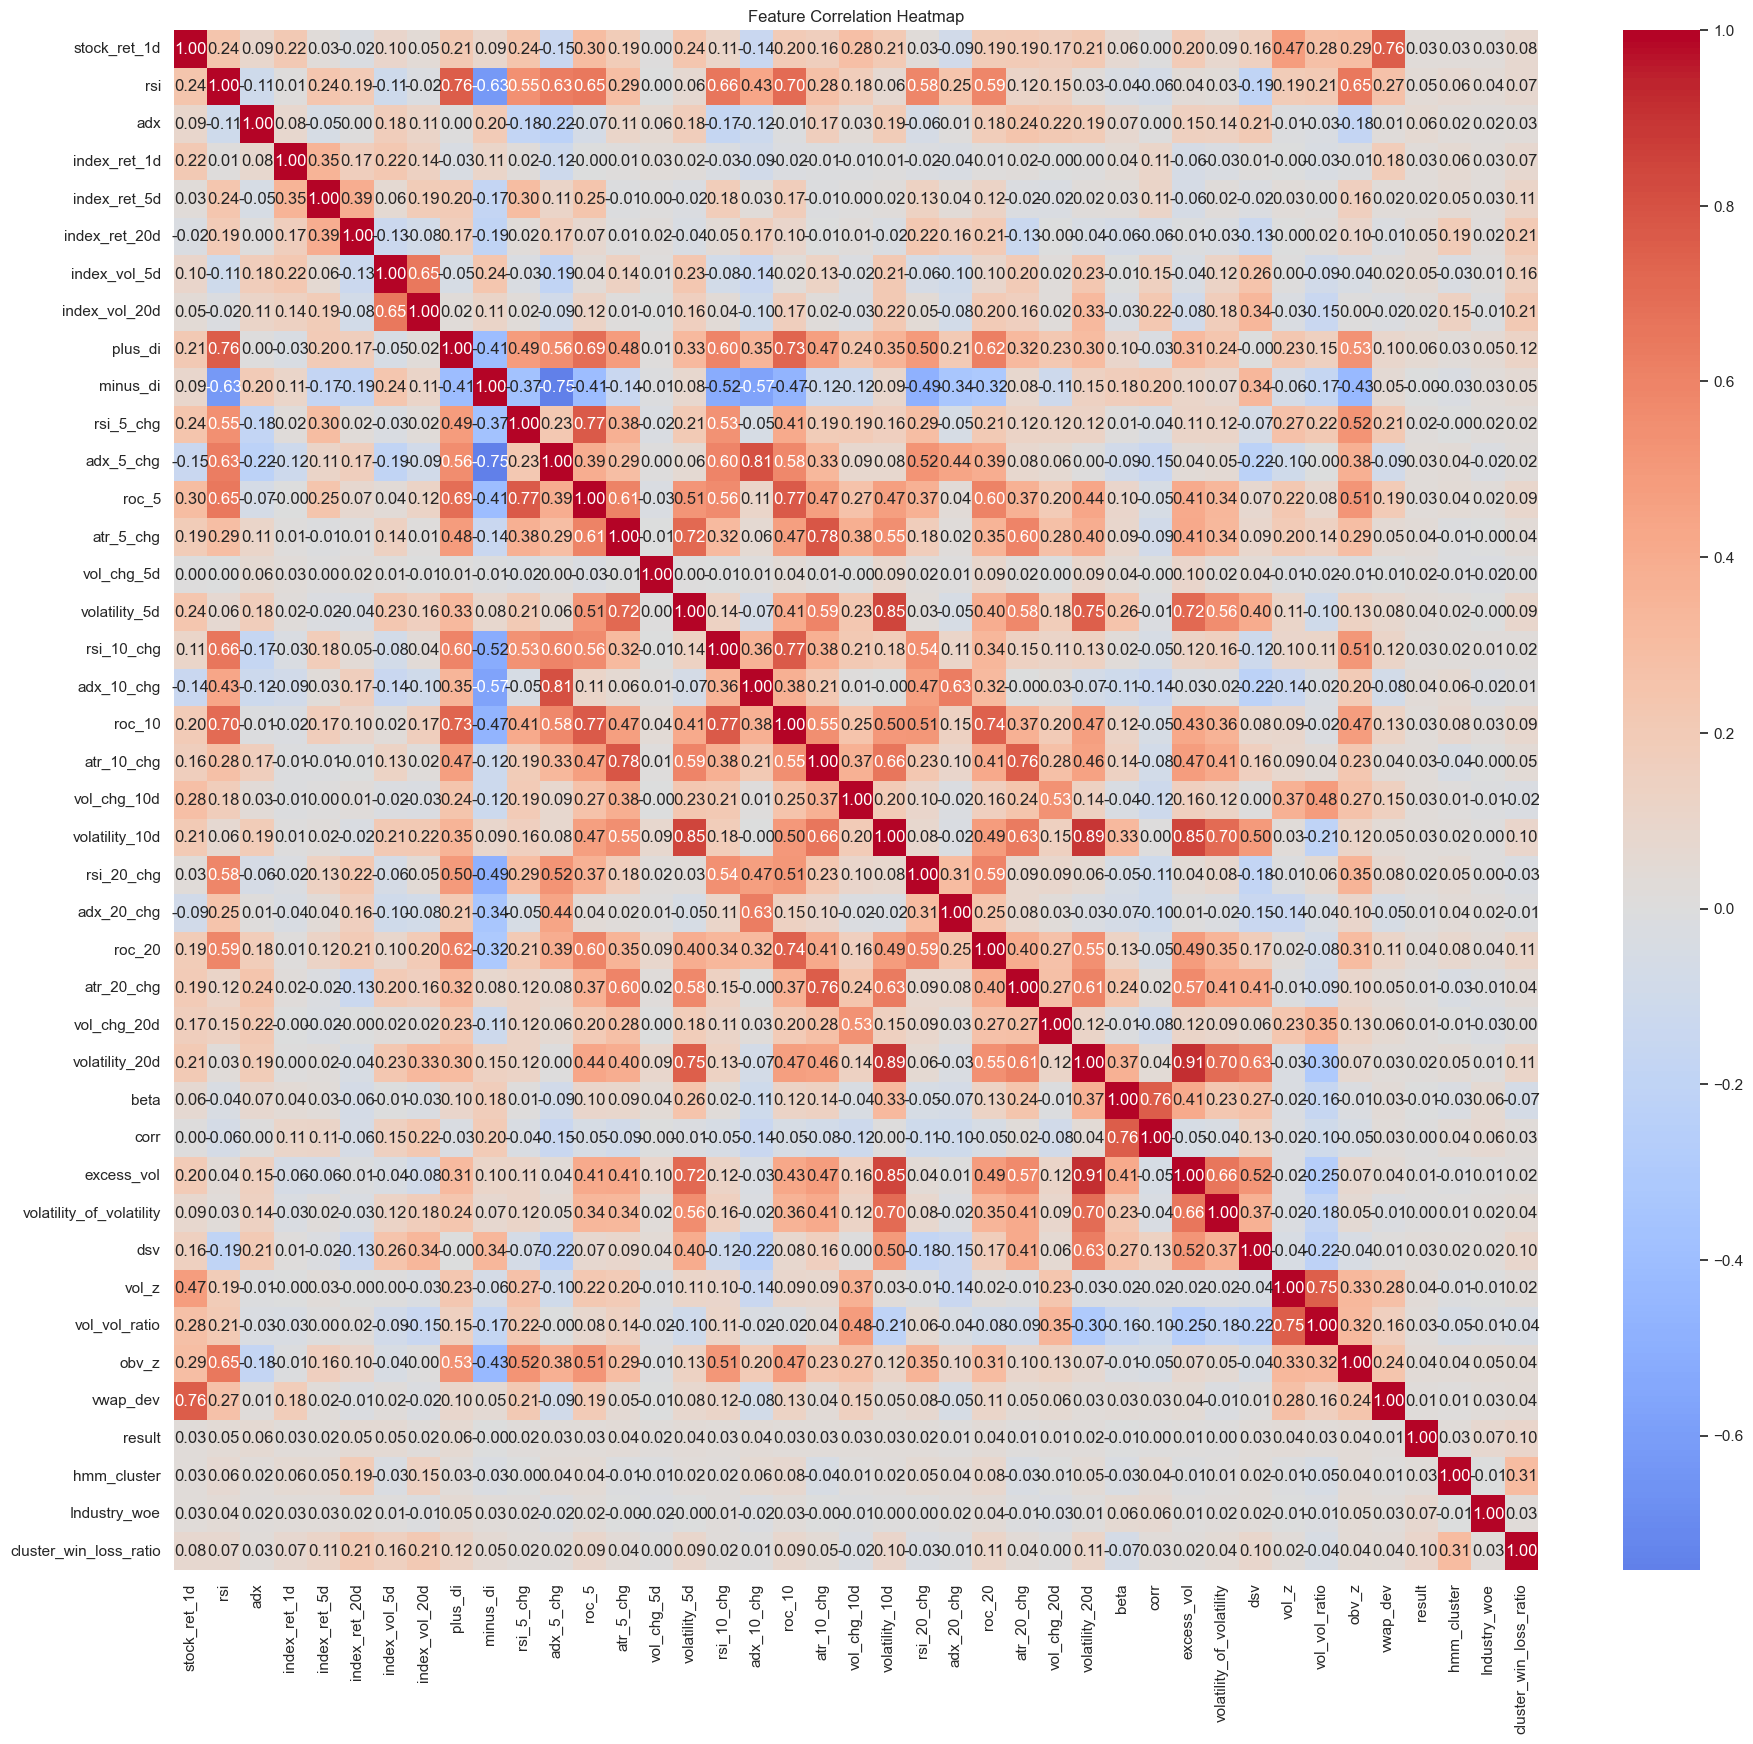

In [268]:
plt.figure(figsize=(22,20))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [308]:
temp = df.drop(columns=["result"], axis=1).copy()

In [ ]:

categorical_features = ['hmm_cluster']

# Identify them in your feature matrix
discrete_features = temp.columns.isin(categorical_features)


mi = mutual_info_classif(temp, df["result"], discrete_features=discrete_features, random_state=42)
mi_series = pd.Series(mi, index=temp.columns).sort_values(ascending=False)
selected = mi_series[mi_series > mi_series.median()].index
X_filtered = temp[selected]

In [316]:
mi_series.sort_values(ascending=False)

index_ret_20d               0.049049
index_vol_5d                0.048123
index_vol_20d               0.044577
index_ret_1d                0.043341
index_ret_5d                0.042880
vol_chg_10d                 0.018192
obv_z                       0.017846
vol_chg_5d                  0.014867
plus_di                     0.010645
cluster_win_loss_ratio      0.009469
atr_5_chg                   0.008305
rsi_10_chg                  0.007812
volatility_of_volatility    0.007553
dsv                         0.007408
minus_di                    0.006777
adx                         0.006150
vol_vol_ratio               0.005545
Industry_woe                0.005474
hmm_cluster                 0.005277
vol_chg_20d                 0.003482
vol_z                       0.002378
stock_ret_1d                0.002206
roc_20                      0.002153
beta                        0.001655
rsi                         0.001266
roc_5                       0.001115
atr_10_chg                  0.000974
a

In [270]:
list(X_filtered.columns)

['index_ret_20d',
 'index_vol_5d',
 'index_vol_20d',
 'index_ret_1d',
 'index_ret_5d',
 'vol_chg_10d',
 'obv_z',
 'vol_chg_5d',
 'plus_di',
 'cluster_win_loss_ratio',
 'atr_5_chg',
 'rsi_10_chg',
 'volatility_of_volatility',
 'dsv',
 'minus_di',
 'adx',
 'vol_vol_ratio',
 'Industry_woe',
 'hmm_cluster',
 'vol_chg_20d']

In [297]:
temp

,stock_ret_1d,rsi,adx,index_ret_1d,index_ret_5d,index_ret_20d,index_vol_5d,index_vol_20d,plus_di,minus_di,...,excess_vol,volatility_of_volatility,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,hmm_cluster,Industry_woe,cluster_win_loss_ratio
2396,-0.015344,75.574806,33.866604,0.006212,0.042853,0.032008,0.008721,0.015809,42.862165,12.001263,...,0.023462,0.004685,0.000438,-0.943376,13.231202,1.863594,0.137517,0.0,0.171921,0.815166
1419,0.009390,66.985118,30.847063,0.013137,0.021953,0.068439,0.009521,0.011955,31.471365,16.168162,...,0.017277,0.004331,0.000358,-0.152065,33.855358,0.968967,0.063425,3.0,0.171921,0.512195
3240,0.004467,73.931740,30.156950,0.013137,0.021953,0.068439,0.009521,0.011955,31.415420,11.422246,...,0.008765,0.008066,0.000155,-0.579234,35.126138,1.071643,0.016532,3.0,0.171921,0.512195
598,-0.007776,68.502922,30.521119,0.001382,0.034086,0.066397,0.005619,0.011964,24.215227,6.557481,...,0.001272,0.002222,0.000175,0.457509,83.115273,1.333358,0.015242,3.0,-0.170878,0.512195
2815,0.010171,67.560319,30.172319,0.001382,0.034086,0.066397,0.005619,0.011964,29.992586,11.015276,...,0.000139,0.002951,0.000280,0.116702,80.890779,1.781608,0.113989,3.0,0.041870,0.512195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1692,0.000000,57.705115,30.314948,-0.008544,-0.021942,-0.012900,0.006526,0.006253,24.629198,10.955127,...,0.006613,0.000636,0.000106,3.992301,603.398978,0.451727,0.000000,1.0,-0.240706,0.744048
3580,0.000000,68.060884,31.580026,-0.008544,-0.021942,-0.012900,0.006526,0.006253,32.114406,9.375004,...,0.011088,0.001744,0.000392,1.153450,218.252956,2.544196,0.000000,1.0,0.189966,0.744048
3360,-0.002447,64.093506,31.060234,-0.003022,-0.026188,-0.017228,0.005823,0.006257,32.793803,12.005358,...,0.002487,0.001865,0.000062,-0.379968,97.851273,1.078735,0.072640,1.0,0.183092,0.744048
2209,-0.004041,53.859737,30.395963,-0.003022,-0.026188,-0.017228,0.005823,0.006257,31.244059,14.836225,...,0.006780,0.001349,0.000116,-0.450856,49.298656,0.452576,-0.124731,1.0,-0.029508,0.744048


In [313]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rfecv = RFECV(rf, cv=StratifiedKFold(5), scoring='roc_auc', n_jobs=-1)
rfecv.fit(temp, df["result"])

RFECV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
      estimator=RandomForestClassifier(n_estimators=200, random_state=42),
      n_jobs=-1, scoring='roc_auc')

In [314]:
best_features = temp.columns[rfecv.support_]
print("Best subset:", best_features)

Best subset: Index(['rsi', 'volatility_5d'], dtype='object')


In [207]:
cols = [
       'atr_10_chg', 'atr_20_chg',
    'index_ret_5d', 'index_ret_20d', 'index_vol_5d', 'index_vol_20d', 'vol_chg_10d', 'vol_chg_20d', 'vol_chg_5d', 'volatility_10d', 'volatility_20d','hmm_cluster',
    'result' ]

In [ ]:
df = df[list(best_features) + ['result', ""]]

In [274]:
df.columns

Index(['index_ret_20d', 'index_vol_5d', 'index_vol_20d', 'index_ret_1d',
       'index_ret_5d', 'vol_chg_10d', 'obv_z', 'vol_chg_5d', 'plus_di',
       'atr_5_chg', 'rsi_10_chg', 'volatility_of_volatility', 'dsv',
       'minus_di', 'adx', 'vol_vol_ratio', 'Industry_woe', 'vol_chg_20d',
       'result'],
      dtype='object')

In [275]:
# X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=["result"]), df["result"], test_size=0.2, random_state=42, stratify=df["result"])

# get first 80% of rows as training set and last 20% as test set
train_size = int(0.8 * len(df))
X_train = df.drop(columns=["result"]).iloc[:train_size]
X_test = df.drop(columns=["result"]).iloc[train_size:]
y_train = df["result"].iloc[:train_size]
y_test = df["result"].iloc[train_size:]

In [276]:
X_train

,index_ret_20d,index_vol_5d,index_vol_20d,index_ret_1d,index_ret_5d,vol_chg_10d,obv_z,vol_chg_5d,plus_di,atr_5_chg,rsi_10_chg,volatility_of_volatility,dsv,minus_di,adx,vol_vol_ratio,Industry_woe,vol_chg_20d
2396,0.032008,0.008721,0.015809,0.006212,0.042853,-0.597268,1.863594,0.059312,42.862165,0.153988,0.186468,0.004685,0.000438,12.001263,33.866604,13.231202,0.171921,0.814865
1419,0.068439,0.009521,0.011955,0.013137,0.021953,-0.221978,0.968967,0.855372,31.471365,-0.018998,0.008636,0.004331,0.000358,16.168162,30.847063,33.855358,0.171921,1.037568
3240,0.068439,0.009521,0.011955,0.013137,0.021953,-0.383685,1.071643,0.271385,31.415420,-0.093495,0.004306,0.008066,0.000155,11.422246,30.156950,35.126138,0.171921,-0.165259
598,0.066397,0.005619,0.011964,0.001382,0.034086,0.848752,1.333358,0.916172,24.215227,0.059412,0.134275,0.002222,0.000175,6.557481,30.521119,83.115273,-0.170878,0.280783
2815,0.066397,0.005619,0.011964,0.001382,0.034086,0.159604,1.781608,0.462028,29.992586,-0.068499,0.074886,0.002951,0.000280,11.015276,30.172319,80.890779,0.041870,0.200661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3666,-0.020814,0.003874,0.004556,0.001896,-0.002774,-0.203771,-0.570426,0.159383,15.770438,-0.026385,-0.201497,0.001165,0.000125,14.935649,38.176930,67.572598,-0.119259,0.251261
368,-0.020814,0.003874,0.004556,0.001896,-0.002774,-0.589547,-0.999341,-0.485737,19.216169,-0.106885,-0.300429,0.002172,0.000051,17.588977,34.814486,62.190683,-0.119259,-0.193926
1587,-0.019566,0.003560,0.004565,0.000248,-0.004966,1.326960,1.796365,2.002261,33.626873,0.232574,0.506935,0.002717,0.000358,10.344886,30.190714,39.682188,-0.170878,2.562465
644,-0.013968,0.003904,0.004096,-0.004840,-0.006855,5.179753,2.949174,0.587746,39.707052,0.066386,0.333675,0.005591,0.000325,12.163352,30.236547,57.817787,0.092264,1.390913


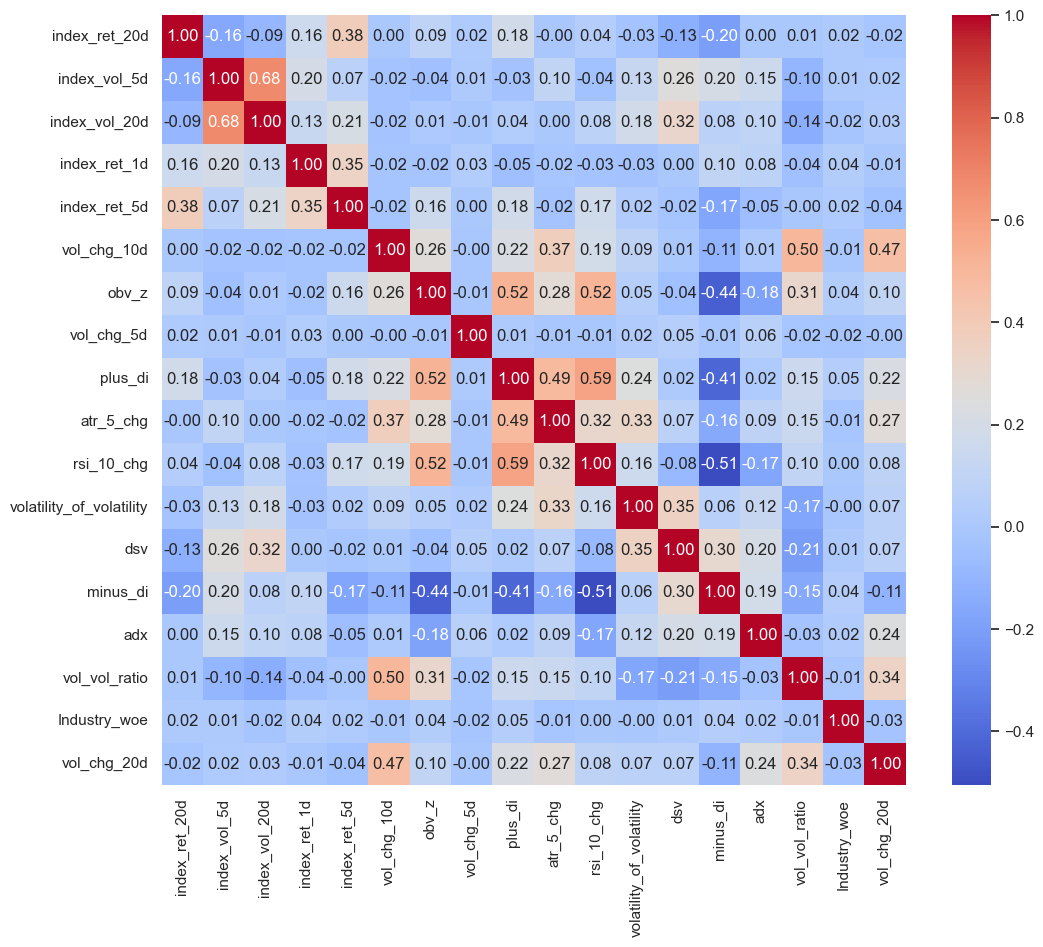

In [277]:
plt.figure(figsize=(12,10))
sns.heatmap(X_train.corr(), annot=True, fmt=".2f", cmap="coolwarm");

In [278]:
# one_hot_cols = ["hmm_cluster"]
# ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# train_ohe = ohe.fit_transform(X_train[one_hot_cols])
# test_ohe = ohe.transform(X_test[one_hot_cols])

# train_ohe_df = pd.DataFrame(train_ohe, columns=ohe.get_feature_names_out(one_hot_cols), index=X_train.index)
# test_ohe_df = pd.DataFrame(test_ohe, columns=ohe.get_feature_names_out(one_hot_cols), index=X_test.index)

# X_train_ohe = pd.concat([X_train.drop(columns=one_hot_cols), train_ohe_df], axis=1)
# X_test_ohe = pd.concat([X_test.drop(columns=one_hot_cols), test_ohe_df], axis=1)

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [279]:
X_train_scaled

,index_ret_20d,index_vol_5d,index_vol_20d,index_ret_1d,index_ret_5d,vol_chg_10d,obv_z,vol_chg_5d,plus_di,atr_5_chg,rsi_10_chg,volatility_of_volatility,dsv,minus_di,adx,vol_vol_ratio,Industry_woe,vol_chg_20d
2396,-0.046592,0.283342,1.781101,0.503931,1.877263,-0.386279,0.442689,-0.018683,1.589938,0.410450,0.026450,0.554228,0.337107,0.075480,0.588947,-0.887636,1.219302,-0.104753
1419,1.010940,0.457729,0.888440,1.387083,0.707917,-0.320185,-0.503015,-0.018522,-0.088678,-0.625190,-0.658068,0.429998,0.142131,1.103692,-0.344630,-0.573779,1.219302,-0.081846
3240,1.010940,0.457729,0.888440,1.387083,0.707917,-0.348664,-0.394476,-0.018640,-0.096922,-1.071189,-0.674734,1.741256,-0.353661,-0.067396,-0.557998,-0.554441,1.219302,-0.205568
598,0.951642,-0.393152,0.890383,-0.112020,1.386718,-0.131614,-0.117820,-0.018509,-1.157985,-0.155763,-0.174451,-0.310331,-0.305501,-1.267811,-0.445405,0.175853,-1.210061,-0.159688
2815,0.951642,-0.393152,0.890383,-0.112020,1.386718,-0.252983,0.356022,-0.018601,-0.306599,-0.921546,-0.403054,-0.054521,-0.048029,-0.167819,-0.553247,0.142001,0.297653,-0.167929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3666,-1.579888,-0.773764,-0.825596,-0.046543,-0.675532,-0.316979,-2.130293,-0.018663,-2.402459,-0.669416,-1.466918,-0.681445,-0.426800,0.799561,1.921607,-0.060674,-0.844248,-0.162725
368,-1.579888,-0.773764,-0.825596,-0.046543,-0.675532,-0.384920,-2.583696,-0.018793,-1.894676,-1.151354,-1.847733,-0.327866,-0.607101,1.454288,0.882011,-0.142575,-0.844248,-0.208516
1587,-1.543662,-0.842265,-0.823482,-0.256671,-0.798170,-0.047395,0.371621,-0.018289,0.228971,0.880932,1.260007,-0.136717,0.142766,-0.333243,-0.547559,-0.485107,-1.210061,0.075003
644,-1.381176,-0.767188,-0.932092,-0.905602,-0.903889,0.631139,1.590246,-0.018576,1.124982,-0.114012,0.593087,0.872423,0.062262,0.115477,-0.533389,-0.209122,0.654786,-0.045501


In [280]:
# calculate class weights
class_weights = y_train.value_counts(normalize=True)
class_weights = {cls: 1/weight for cls, weight in class_weights.items()}
class_weights

{0: 1.680022896393818, 1: 2.4705387205387206}

In [281]:
# class_weights = {0: 1, 1: 1.2}

In [282]:
class_weights[0]

1.680022896393818

In [283]:
X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape

((2935, 18), (734, 18), (2935,), (734,))

In [284]:
def y_train_shuffle(random_state=42):
    return y_train.sample(frac=1, random_state=random_state).reset_index(drop=True).copy()

# Logistic Regression

In [290]:
# optuna for logistic regression
def objective(trial):
    # Define the hyperparameters to tune
    C = trial.suggest_float('C', 1e-5, 10.0, log=True)
    
    # Create the model with the suggested hyperparameters
    model = LogisticRegression(C=C,  class_weight=class_weights, random_state=42, max_iter=1000)
    
    # Perform cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='f1')
    
    # Return the average F1 score across folds
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print("Best trial:")
trial = study.best_trial
print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-10-09 01:39:55,717] A new study created in memory with name: no-name-dbbadc22-57a7-4f41-81b6-e0a4277b3326
[I 2025-10-09 01:39:55,738] Trial 0 finished with value: 0.4714307204529568 and parameters: {'C': 0.002129843408829933}. Best is trial 0 with value: 0.4714307204529568.
[I 2025-10-09 01:39:55,755] Trial 1 finished with value: 0.4761037142087671 and parameters: {'C': 0.0015288167605487383}. Best is trial 1 with value: 0.4761037142087671.
[I 2025-10-09 01:39:55,770] Trial 2 finished with value: 0.4690671453832434 and parameters: {'C': 0.004362992889335326}. Best is trial 1 with value: 0.4761037142087671.
[I 2025-10-09 01:39:55,786] Trial 3 finished with value: 0.46946567903684205 and parameters: {'C': 1.8717640375677884e-05}. Best is trial 1 with value: 0.4761037142087671.
[I 2025-10-09 01:39:55,801] Trial 4 finished with value: 0.4662629061237456 and parameters: {'C': 0.01001615010234353}. Best is trial 1 with value: 0.4761037142087671.
[I 2025-10-09 01:39:55,813] Trial 5 fi

Best trial:
  Value: 0.48011462952503015
  Params: 
    C: 0.00022880806574850234


              precision    recall  f1-score   support

           0       0.64      0.65      0.64       419
           1       0.52      0.50      0.51       315

    accuracy                           0.59       734
   macro avg       0.58      0.58      0.58       734
weighted avg       0.59      0.59      0.59       734



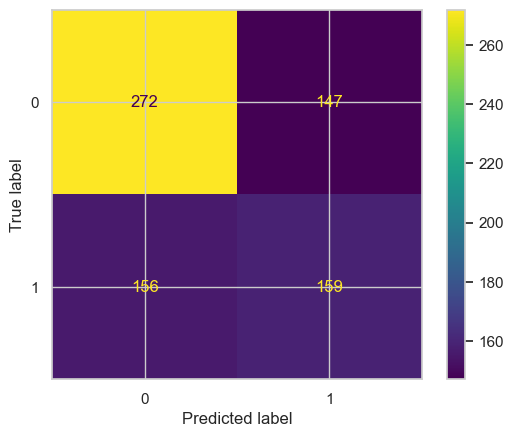

In [292]:
lr = LogisticRegression(class_weight=class_weights, random_state=42, max_iter=1000, C=trial.params['C'])
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=lr.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
disp.plot()
plt.show()

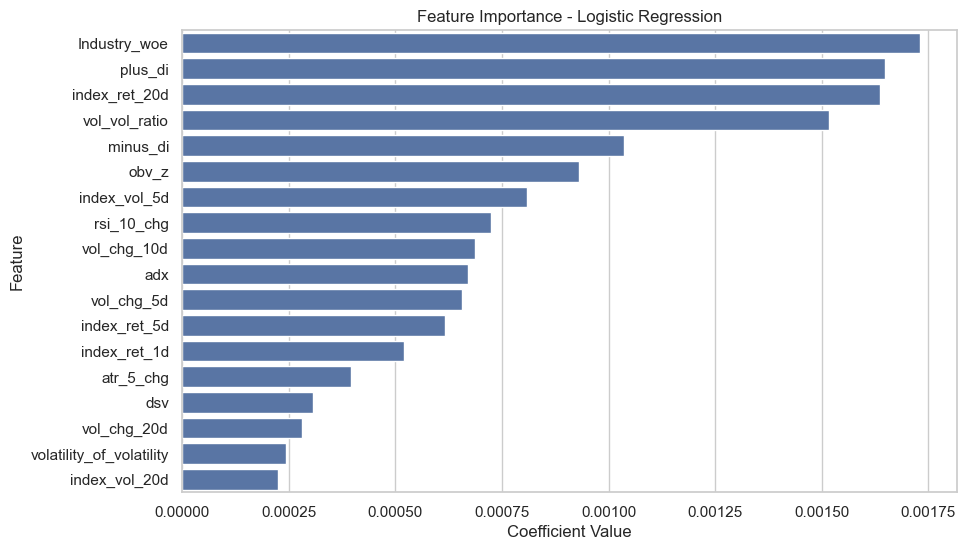

In [286]:
# feature importance
feat_importance = pd.Series(lr.coef_[0], index=X_train_scaled.columns)
feat_importance = feat_importance.abs()
feat_importance = feat_importance.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feat_importance.values, y=feat_importance.index)
plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

# XGBoost

In [287]:
def objective_xgb(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 32),
          'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': class_weights[1] / class_weights[0]  # handle class imbalance
    }
    
    model = XGBClassifier(**param, random_state=42, n_jobs=-1)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    return f1
    
    

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100, n_jobs=-1)
print("Best trial:")
trial = study_xgb.best_trial
print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-10-08 23:35:10,516] A new study created in memory with name: no-name-7607fab9-ddc0-4815-a4dd-2196317a5c70
[I 2025-10-08 23:35:15,386] Trial 9 finished with value: 0.3281853281853282 and parameters: {'max_depth': 11, 'learning_rate': 0.07142908958315752, 'n_estimators': 54, 'subsample': 0.8299806275204774, 'colsample_bytree': 0.5300444343833627}. Best is trial 9 with value: 0.3281853281853282.
[I 2025-10-08 23:35:17,339] Trial 14 finished with value: 0.3230769230769231 and parameters: {'max_depth': 13, 'learning_rate': 0.15933532269199913, 'n_estimators': 63, 'subsample': 0.9986008003122187, 'colsample_bytree': 0.7675340996628602}. Best is trial 9 with value: 0.3281853281853282.
[I 2025-10-08 23:35:19,446] Trial 7 finished with value: 0.3609022556390977 and parameters: {'max_depth': 10, 'learning_rate': 0.2879816511974011, 'n_estimators': 110, 'subsample': 0.7865193072433403, 'colsample_bytree': 0.503851394363258}. Best is trial 7 with value: 0.3609022556390977.
[I 2025-10-08 23

Best trial:
  Value: 0.4144144144144144
  Params: 
    max_depth: 3
    learning_rate: 0.20213008372751942
    n_estimators: 391
    subsample: 0.8262367747041366
    colsample_bytree: 0.9291262489556845


In [258]:
print("Best trials:")
for trial in study_xgb.best_trials:
    print(f"  Values: {trial.values}")
    print("  Params: ")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")

Best trials:
  Values: [0.646551724137931, 0.3925925925925926]
  Params: 
    max_depth: 6
    learning_rate: 0.2755991706281744
    n_estimators: 253
  Values: [0.6553911205073996, 0.37547892720306514]
  Params: 
    max_depth: 13
    learning_rate: 0.07213807324861908
    n_estimators: 261
  Values: [0.6488794023479189, 0.3804143126177024]
  Params: 
    max_depth: 15
    learning_rate: 0.1562396326207755
    n_estimators: 435


              precision    recall  f1-score   support

           0       0.58      0.70      0.64       419
           1       0.45      0.32      0.38       315

    accuracy                           0.54       734
   macro avg       0.52      0.51      0.51       734
weighted avg       0.53      0.54      0.53       734



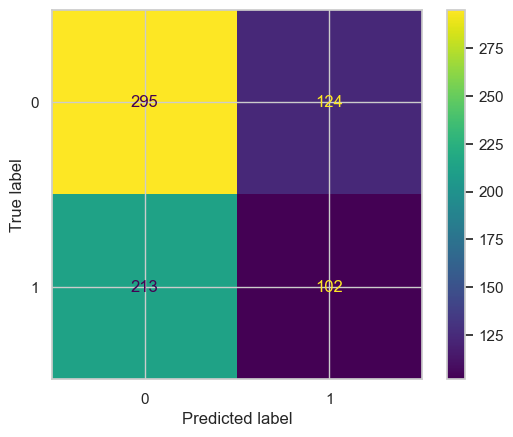

CPU times: user 415 ms, sys: 4.37 s, total: 4.79 s
Wall time: 736 ms


In [289]:
%%time
xgb = XGBClassifier(**trial.params, random_state=42, n_jobs=-1)
# xgb = XGBClassifier(scale_pos_weight=class_weights[1]/class_weights[0], n_estimators=50, learning_rate=0.2450478621569601, random_state=42, n_jobs=-1, max_depth=3,  eval_metric= 'logloss')
xgb.fit(X_train_scaled, y_train)
y_pred = xgb.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=xgb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb.classes_)
disp.plot()
plt.show()

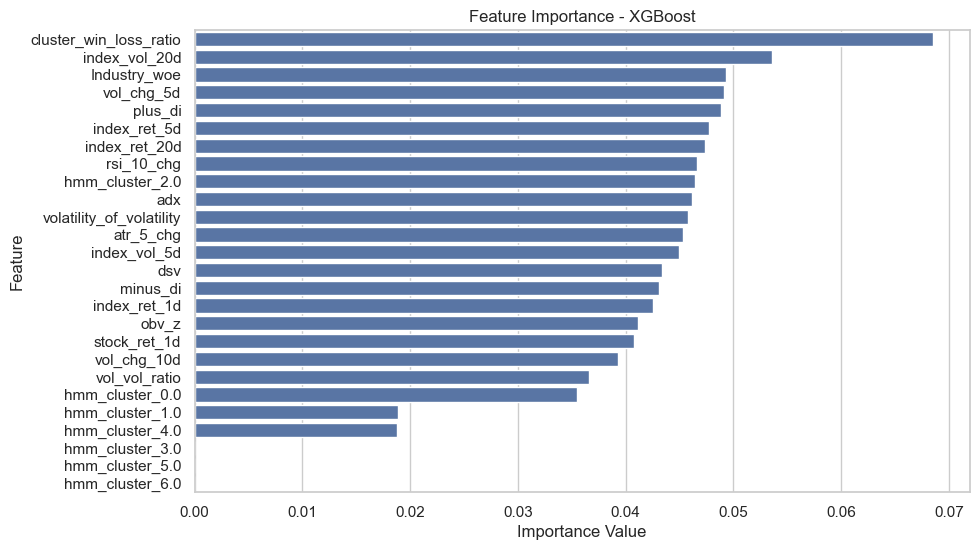

In [225]:
# feature importance xgb
feat_importance = pd.Series(xgb.feature_importances_, index=X_train_scaled.columns)
feat_importance = feat_importance.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feat_importance.values, y=feat_importance.index)
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Value")
plt.ylabel("Feature")
plt.show()